In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import data_analytics_lib as dal
import random

# Exercise 1

## Write a Python function to read in the data. The data file is named driving_clustering_data.txt. Plot the raw data for the distance feature and speeding features. Make the distance feature the independent value and the speeding feature the dependent value for the plot. Write a Python function that will take as inputs the raw feature data (distance and speed) and return the normalized data for each feature. Plot the normalized data for the distance feature and speeding features. Makethe normalized distance feature the independent value and the normalized speeding feature the dependent value for the plot.

In [2]:
def read_data(file):
    
    driver_id = []
    driving_feature = []
    speeding_feature = []
    
    with open(file, 'r') as f:
        
        data = f.readlines()
        
        for line in data[1:]:  # Skip the header line
            line = line.strip().split()
            driver_id.append(float(line[0]))
            driving_feature.append(float(line[1]))
            speeding_feature.append(float(line[2]))

    return driver_id, driving_feature, speeding_feature

driver_id, driving_feature, speeding_feature = read_data('/Users/244213/Desktop/DataAnalytics/Stats/driving_clustering_data.txt')


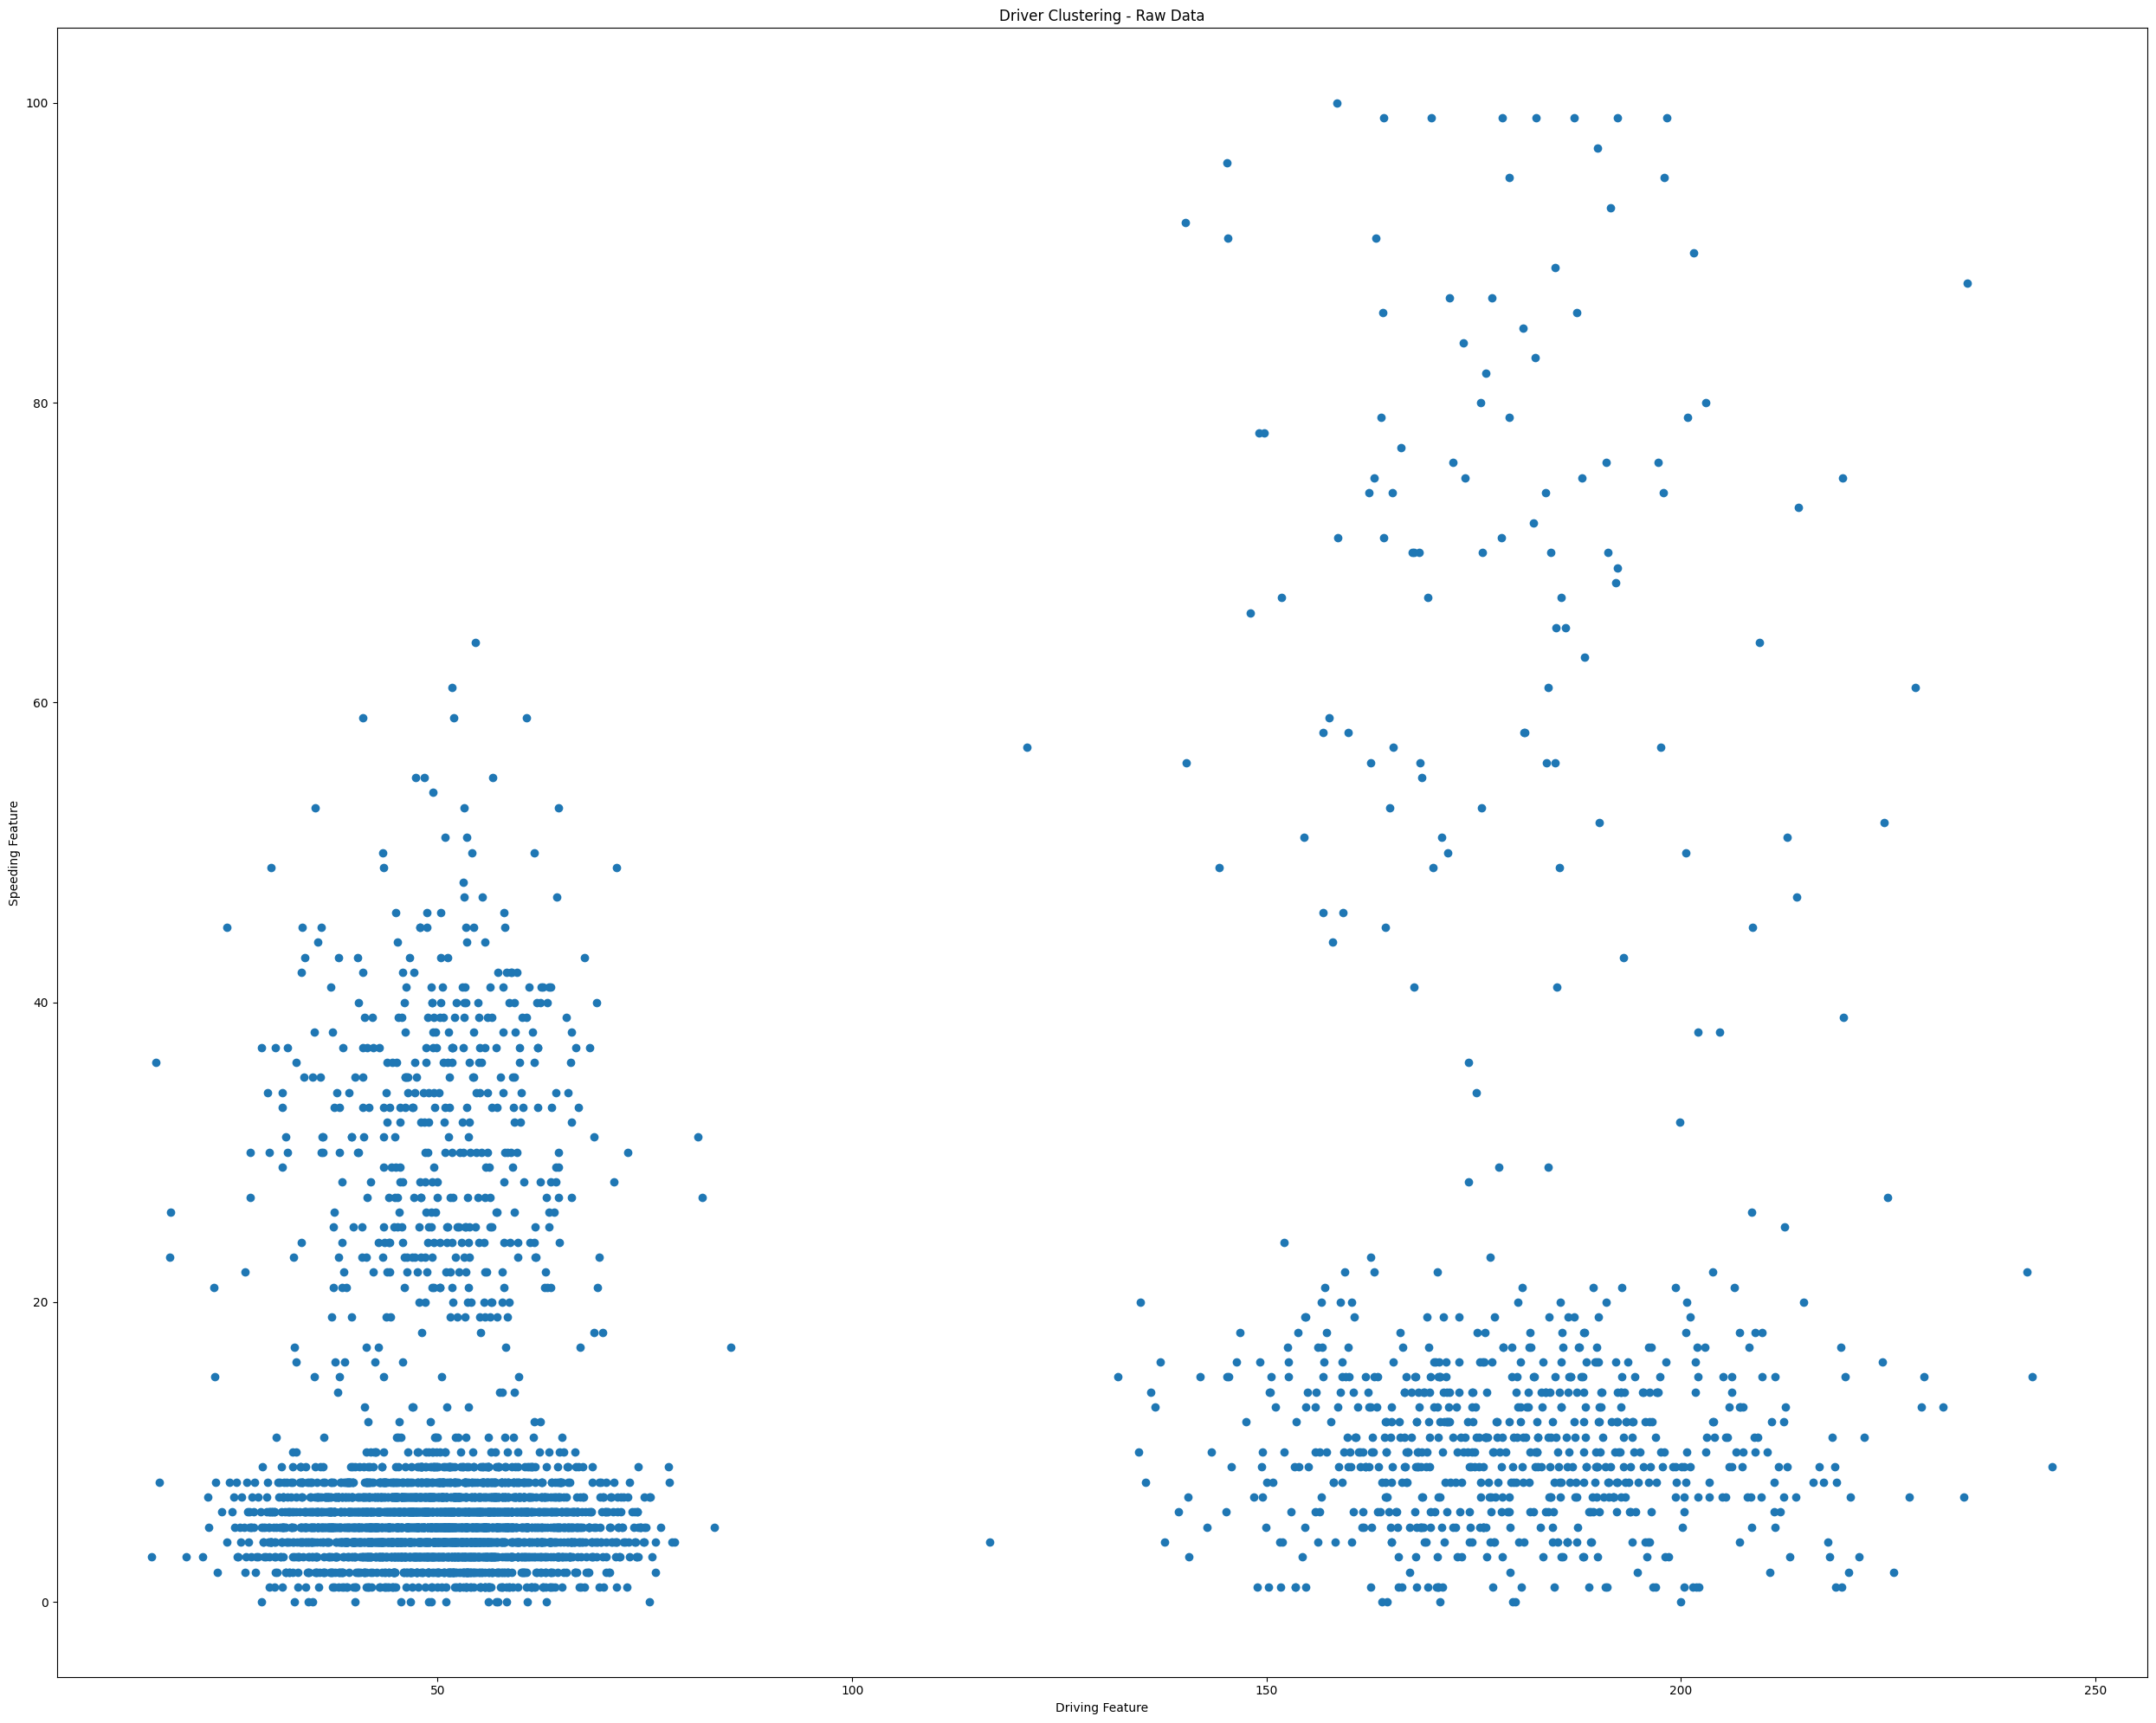

In [3]:
plt.figure(figsize=(25, 20))
plt.scatter(driving_feature, speeding_feature)
plt.xlabel('Driving Feature')
plt.ylabel('Speeding Feature')
plt.title('Driver Clustering - Raw Data')
plt.tight_layout()
plt.show()

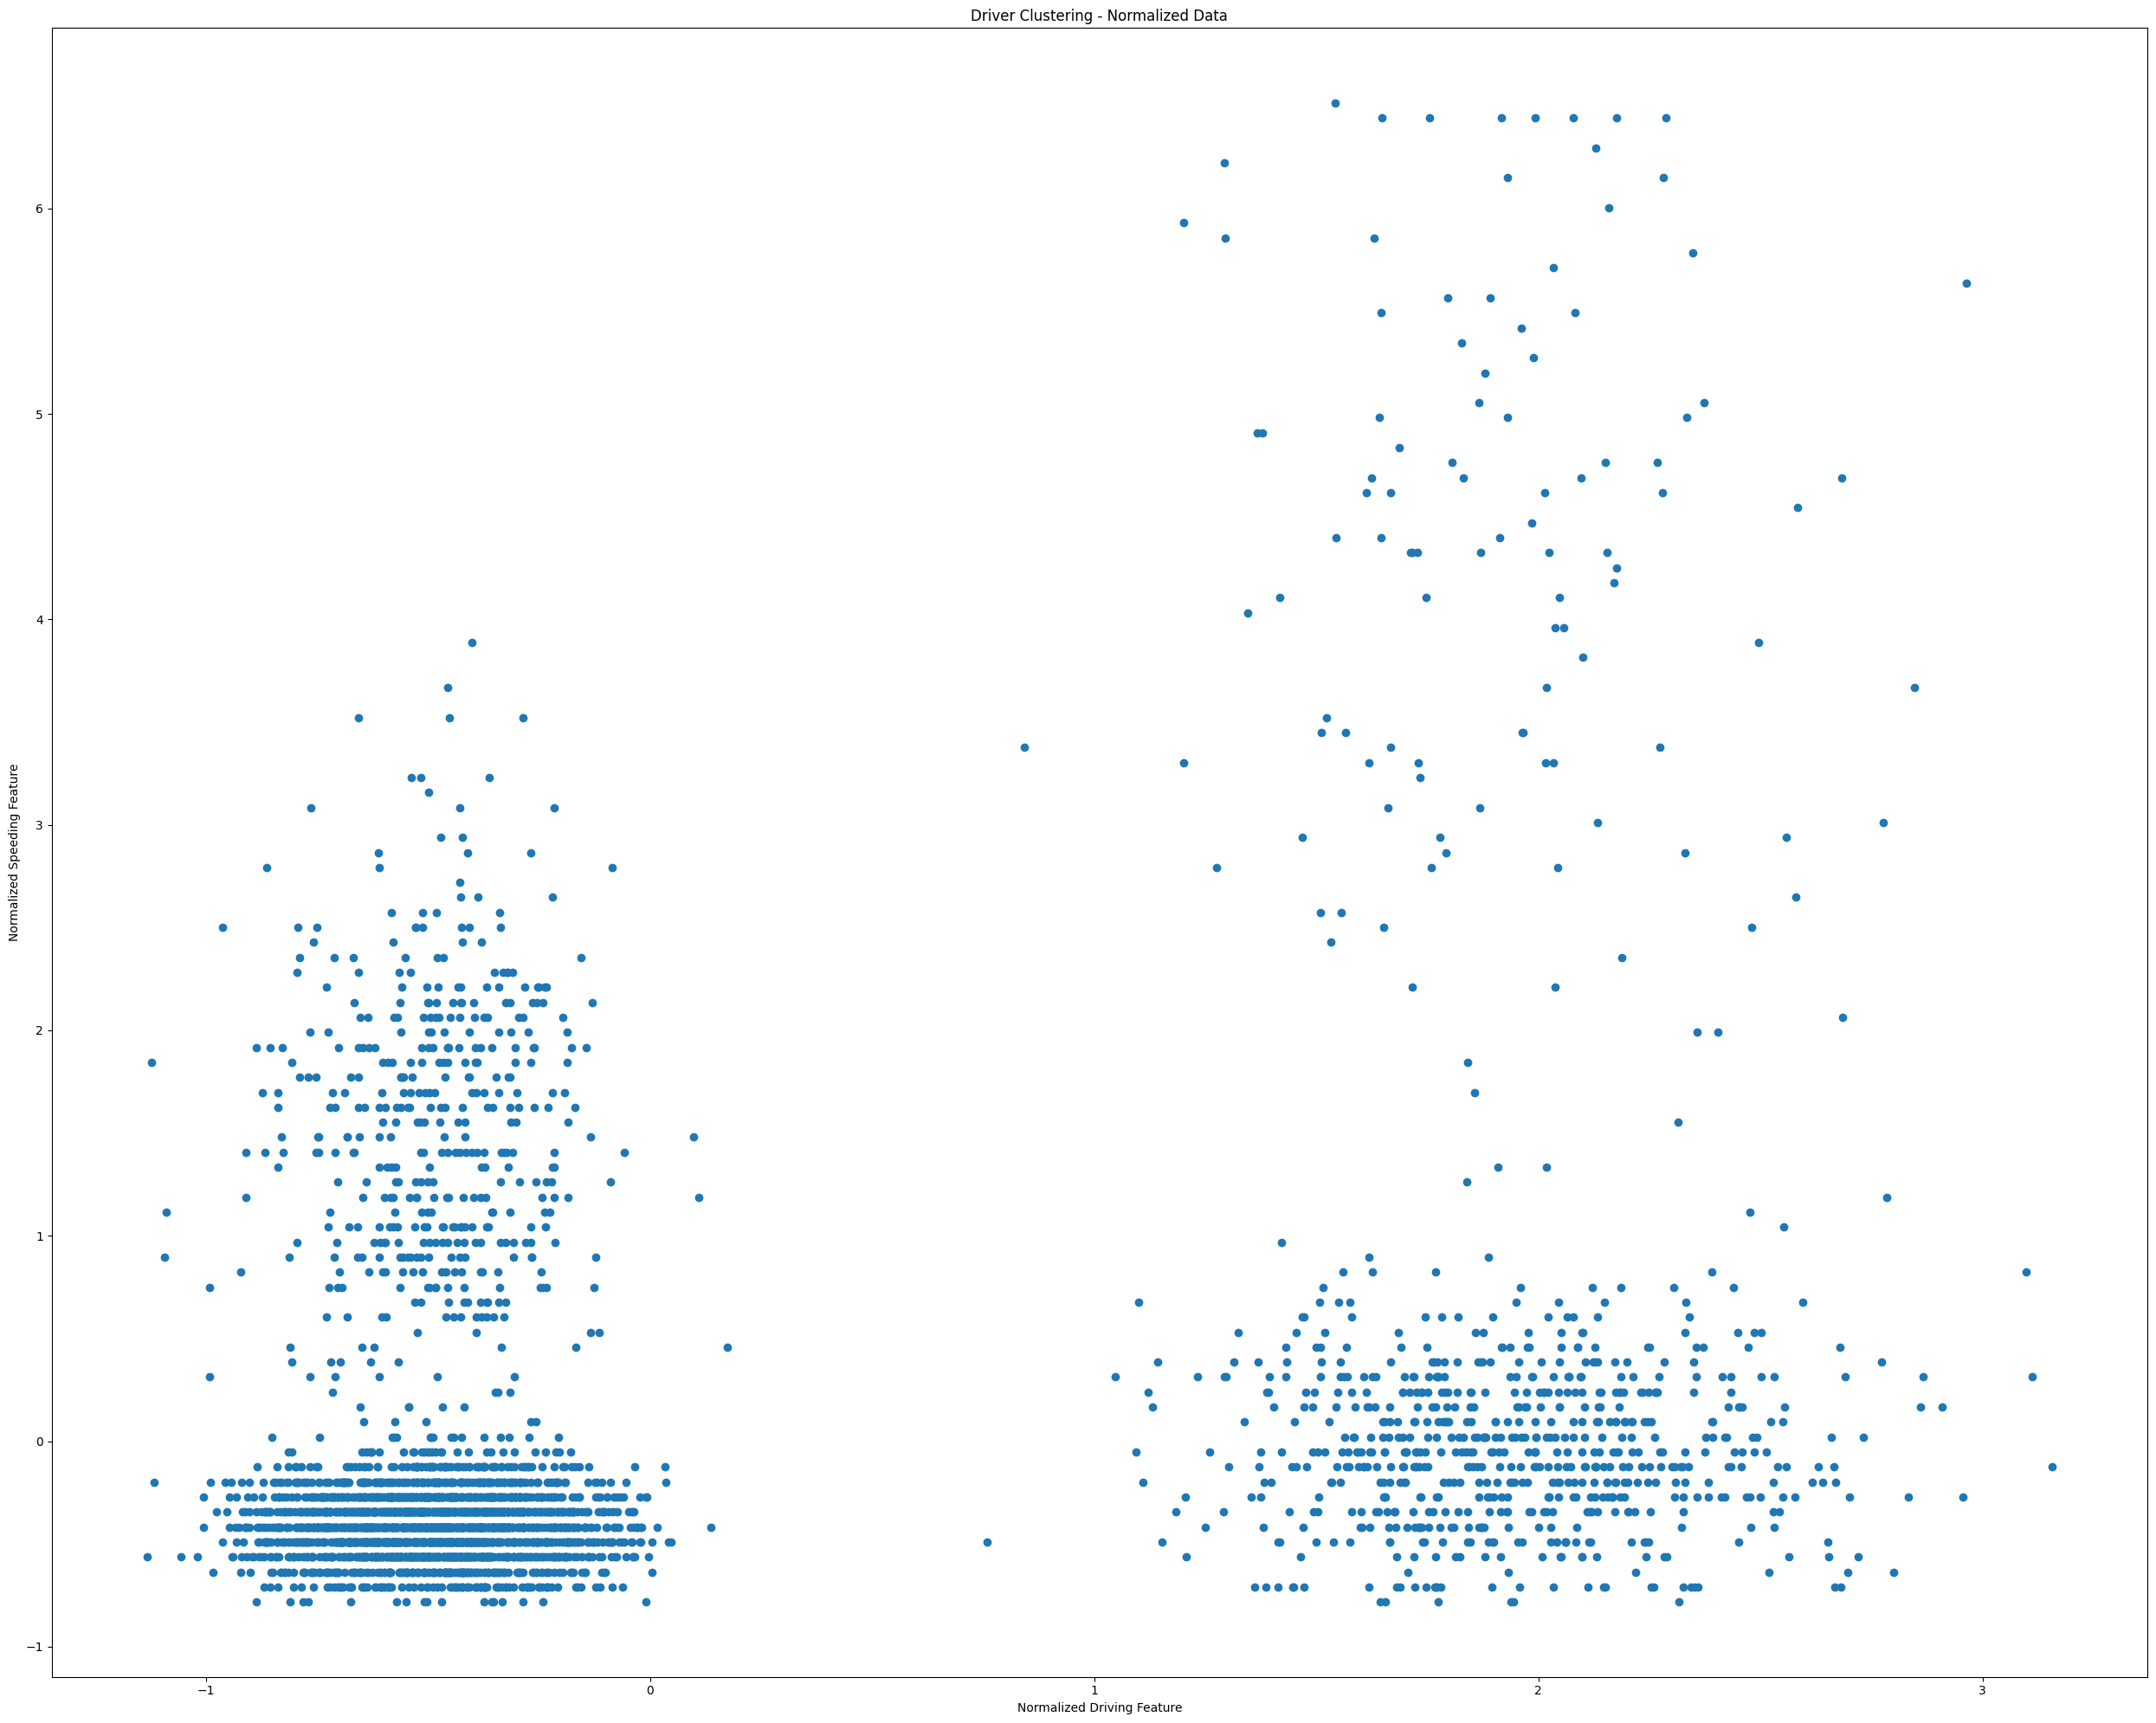

In [4]:
def k_means_normalize_data(feature1, feature2):
    feature1 = np.array(feature1)
    feature2 = np.array(feature2)

    normalized_feature1 = []
    normalized_feature2 = []  

    for i in range(len(feature1)):
        normalized_feature1.append((feature1[i] - np.mean(feature1)) / np.std(feature1))
    for i in range(len(feature2)):
        normalized_feature2.append((feature2[i] - np.mean(feature2)) / np.std(feature2))

    return normalized_feature1, normalized_feature2

normalized_driving_feature, normalized_speeding_feature = k_means_normalize_data(driving_feature, speeding_feature)

plt.figure(figsize=(25, 20))
plt.scatter(normalized_driving_feature, normalized_speeding_feature)
plt.xlabel('Normalized Driving Feature')
plt.ylabel('Normalized Speeding Feature')
plt.title('Driver Clustering - Normalized Data')
plt.tight_layout()
plt.show()


# Exercise 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def k_means_clustering_algorithm(feature1, feature2, x_label = "Feature 1", y_label = "Feature 2", title = "K-Means Clustering"):
    colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']
 
    max_iterations = int(input("Enter the maximum number of iterations: "))
    k = int(input("Enter the number of clusters (k): "))
 
    centroids = []
    for i in range(k):
        x = float(input(f"Enter the x-coordinate of centroid {i+1}: "))
        y = float(input(f"Enter the y-coordinate of centroid {i+1}: "))
        centroids.append([x, y])


    print(f"Initial centroids: {centroids}")


    for iteration in range(max_iterations):
        clusters = {}

        # Assign points using INDEXES
        for j in range(len(feature1)):
            point = np.array([feature1[j], feature2[j]])

            distances = []
            for centroid in centroids:
                dist = np.linalg.norm(point - np.array(centroid))
                distances.append(dist)

            closest_idx = distances.index(min(distances))

            if closest_idx not in clusters:
                clusters[closest_idx] = []

            clusters[closest_idx].append(j)


       # Plot
        plt.figure()
        for cluster_idx in clusters:
            x_vals = [feature1[i] for i in clusters[cluster_idx]]
            y_vals = [feature2[i] for i in clusters[cluster_idx]]

            plt.scatter(x_vals, y_vals, color=colors[cluster_idx % len(colors)], label=f'Cluster {cluster_idx + 1}')

            plt.scatter(centroids[cluster_idx][0], centroids[cluster_idx][1], color='black', marker='X', s=200)

        plt.title(f"{title} - Iteration {iteration + 1}")
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.show()


        # Update centroids using NumPy
        for idx in clusters:
            points = np.array([[feature1[i], feature2[i]] for i in clusters[idx]])
            centroids[idx] = np.mean(points, axis=0).tolist()


        print(f"Updated centroids: {centroids}")


    return clusters


def cluster_stats(cluster_indices, cluster_num, feature1, feature2):
    points = np.array([[feature1[i], feature2[i]] for i in cluster_indices])

    stats = {
    "cluster": cluster_num,
    "size": len(cluster_indices),
    "mean": np.mean(points, axis=0),
    "median": np.median(points, axis=0),
    "std": np.std(points, axis=0),
    "min": np.min(points, axis=0),
    "max": np.max(points, axis=0)
    }

    return stats

clusters = k_means_clustering_algorithm(normalized_driving_feature, normalized_speeding_feature, "Normalized Driving Feature", "Normalized Speeding Feature")

for cluster_num in clusters:
    stats = cluster_stats(clusters[cluster_num], cluster_num, driving_feature, speeding_feature)
    print(stats)



ValueError: invalid literal for int() with base 10: ''

# Project Code

In [6]:


def load_data(filename):

    male_income = []
    male_spending = []
    male_age = []

    female_income = []
    female_spending = []
    female_age = []

    with open(filename, 'r') as file:
        next(file) # skip header

        for line in file:
            lines = line.strip().split(',')

            gender = lines[1]
            age = int(lines[2])
            income = int(lines[3])
            spending = int(lines[4])

            if gender == "Male":
                male_income.append(income)
                male_spending.append(spending)
                male_age.append(age)
            else:
                female_income.append(income)
                female_spending.append(spending)
                female_age.append(age)

    return male_income, male_spending, male_age, female_income, female_spending, female_age

male_income, male_spending, male_age, female_income, female_spending, female_age = load_data('/Users/244213/Desktop/DataAnalytics/Stats/customer_data.txt')


## Income vs Spending

Initial centroids: [[20.0, 20.0], [30.0, 80.0], [60.0, 50.0], [80.0, 20.0], [100.0, 80.0]]


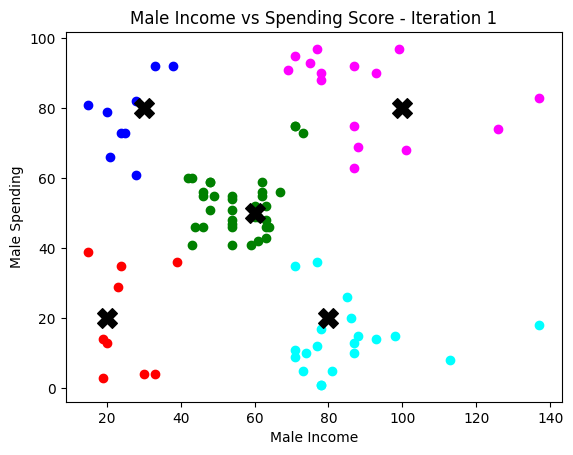

Updated centroids: [[24.666666666666668, 19.666666666666668], [25.77777777777778, 77.66666666666667], [56.17142857142857, 52.77142857142857], [85.15, 14.05], [90.2, 84.33333333333333]]


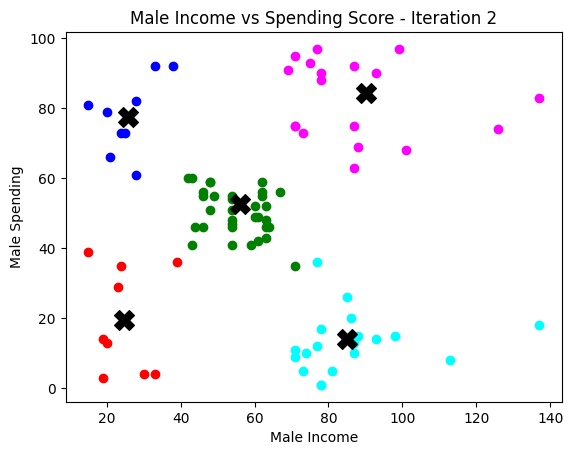

Updated centroids: [[24.666666666666668, 19.666666666666668], [25.77777777777778, 77.66666666666667], [55.21212121212121, 50.27272727272727], [85.89473684210526, 12.947368421052632], [87.11111111111111, 82.66666666666667]]


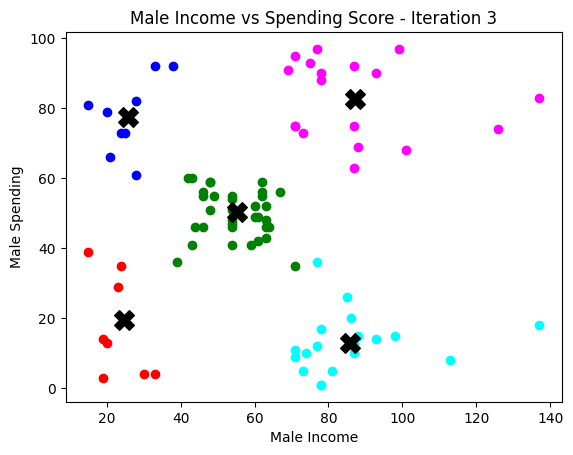

Updated centroids: [[22.875, 17.625], [25.77777777777778, 77.66666666666667], [54.73529411764706, 49.85294117647059], [85.89473684210526, 12.947368421052632], [87.11111111111111, 82.66666666666667]]


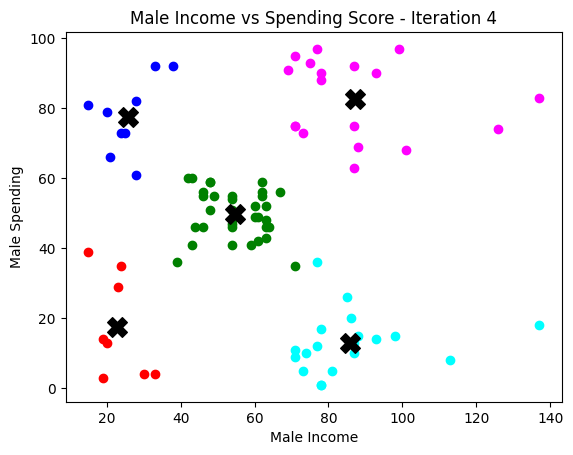

Updated centroids: [[22.875, 17.625], [25.77777777777778, 77.66666666666667], [54.73529411764706, 49.85294117647059], [85.89473684210526, 12.947368421052632], [87.11111111111111, 82.66666666666667]]


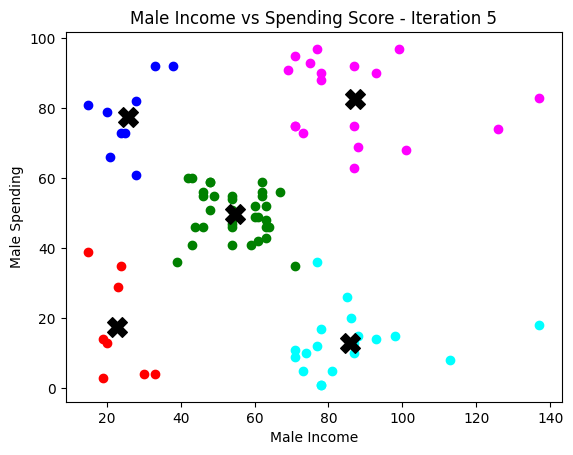

Updated centroids: [[22.875, 17.625], [25.77777777777778, 77.66666666666667], [54.73529411764706, 49.85294117647059], [85.89473684210526, 12.947368421052632], [87.11111111111111, 82.66666666666667]]
{'cluster': 0, 'size': 8, 'mean': array([22.875, 17.625]), 'median': array([21.5, 13.5]), 'std': array([ 5.64441095, 13.72896118]), 'min': array([15,  3]), 'max': array([33, 39])}
{'cluster': 1, 'size': 9, 'mean': array([25.77777778, 77.66666667]), 'median': array([25., 79.]), 'std': array([ 6.56214358, 10.        ]), 'min': array([15, 61]), 'max': array([38, 92])}
{'cluster': 2, 'size': 34, 'mean': array([54.73529412, 49.85294118]), 'median': array([54., 50.]), 'std': array([8.2008207 , 6.75683686]), 'min': array([39, 35]), 'max': array([71, 60])}
{'cluster': 4, 'size': 18, 'mean': array([87.11111111, 82.66666667]), 'median': array([82.5, 85.5]), 'std': array([18.39652409, 10.7909427 ]), 'min': array([69, 63]), 'max': array([137,  97])}
{'cluster': 3, 'size': 19, 'mean': array([85.89473684

In [21]:
male_clusters_income__spending = k_means_clustering_algorithm(male_income, male_spending, "Male Income", "Male Spending", "Male Income vs Spending Score")

for cluster_num in male_clusters_income__spending:
    stats = cluster_stats(male_clusters_income__spending[cluster_num], cluster_num, male_income, male_spending)

    print(stats)


Initial centroids: [[30.0, 20.0], [30.0, 90.0], [55.0, 55.0], [90.0, 20.0], [100.0, 90.0]]


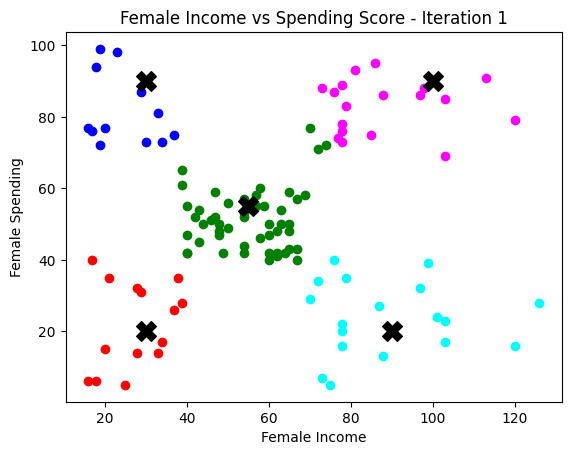

Updated centroids: [[27.357142857142858, 21.714285714285715], [24.583333333333332, 81.83333333333333], [55.28, 51.26], [89.05555555555556, 23.72222222222222], [88.38888888888889, 83.05555555555556]]


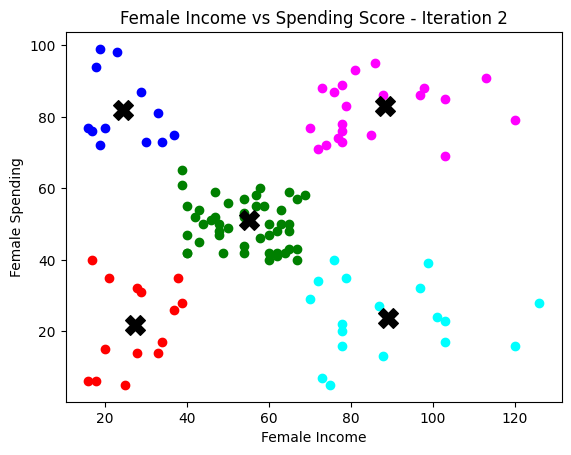

Updated centroids: [[27.357142857142858, 21.714285714285715], [24.583333333333332, 81.83333333333333], [54.212765957446805, 49.851063829787236], [89.05555555555556, 23.72222222222222], [86.04761904761905, 81.66666666666667]]


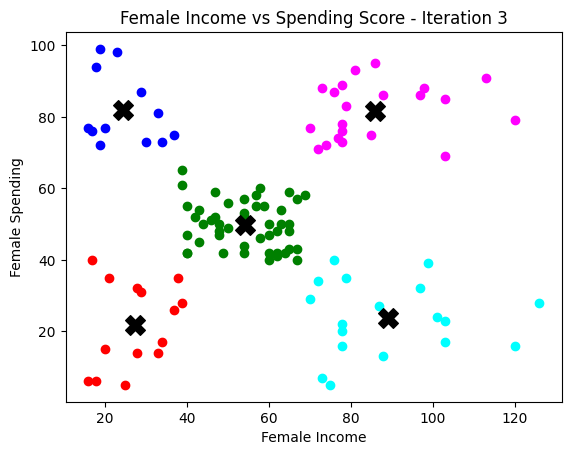

Updated centroids: [[27.357142857142858, 21.714285714285715], [24.583333333333332, 81.83333333333333], [54.212765957446805, 49.851063829787236], [89.05555555555556, 23.72222222222222], [86.04761904761905, 81.66666666666667]]


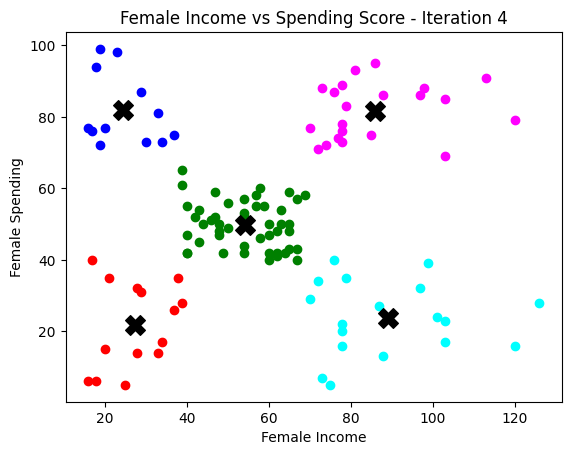

Updated centroids: [[27.357142857142858, 21.714285714285715], [24.583333333333332, 81.83333333333333], [54.212765957446805, 49.851063829787236], [89.05555555555556, 23.72222222222222], [86.04761904761905, 81.66666666666667]]


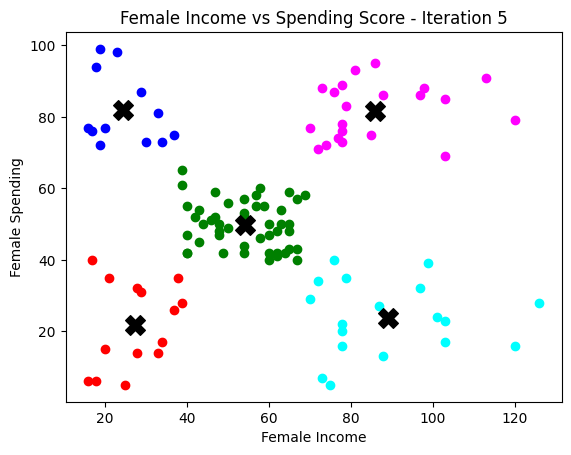

Updated centroids: [[27.357142857142858, 21.714285714285715], [24.583333333333332, 81.83333333333333], [54.212765957446805, 49.851063829787236], [89.05555555555556, 23.72222222222222], [86.04761904761905, 81.66666666666667]]
{'cluster': 0, 'size': 14, 'mean': array([27.35714286, 21.71428571]), 'median': array([28. , 21.5]), 'std': array([ 7.76997098, 11.64000842]), 'min': array([16,  5]), 'max': array([39, 40])}
{'cluster': 1, 'size': 12, 'mean': array([24.58333333, 81.83333333]), 'median': array([21.5, 77. ]), 'std': array([7.20484019, 9.62490981]), 'min': array([16, 72]), 'max': array([37, 99])}
{'cluster': 2, 'size': 47, 'mean': array([54.21276596, 49.85106383]), 'median': array([54., 50.]), 'std': array([9.14873825, 6.42792685]), 'min': array([39, 40]), 'max': array([69, 65])}
{'cluster': 3, 'size': 18, 'mean': array([89.05555556, 23.72222222]), 'median': array([83. , 23.5]), 'std': array([16.27701932,  9.95437121]), 'min': array([70,  5]), 'max': array([126,  40])}
{'cluster': 4, 

In [19]:
female_clusters_income__spending = k_means_clustering_algorithm(female_income, female_spending, "Female Income", "Female Spending", "Female Income vs Spending Score")

for cluster_num in female_clusters_income__spending:
    stats = cluster_stats(female_clusters_income__spending[cluster_num], cluster_num, female_income, female_spending)
    print(stats)


## Age vs income

Initial centroids: [[20.0, 50.0], [40.0, 70.0], [60.0, 60.0], [35.0, 120.0]]


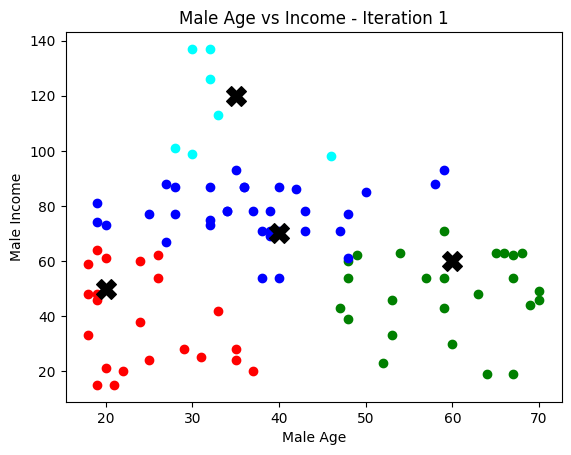

Updated centroids: [[24.454545454545453, 37.95454545454545], [36.8235294117647, 77.20588235294117], [59.28, 48.2], [33.0, 115.85714285714286]]


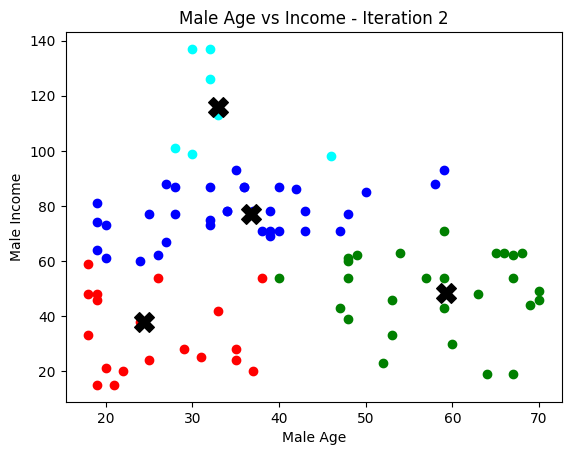

Updated centroids: [[25.63157894736842, 33.78947368421053], [34.714285714285715, 77.22857142857143], [58.148148148148145, 48.888888888888886], [33.0, 115.85714285714286]]


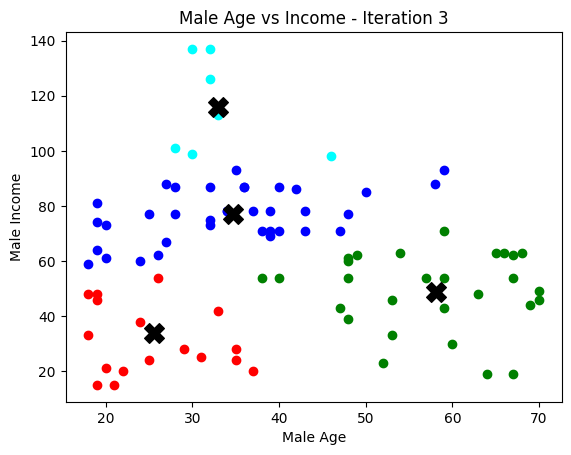

Updated centroids: [[25.352941176470587, 31.11764705882353], [34.25, 76.72222222222223], [57.42857142857143, 49.07142857142857], [33.0, 115.85714285714286]]


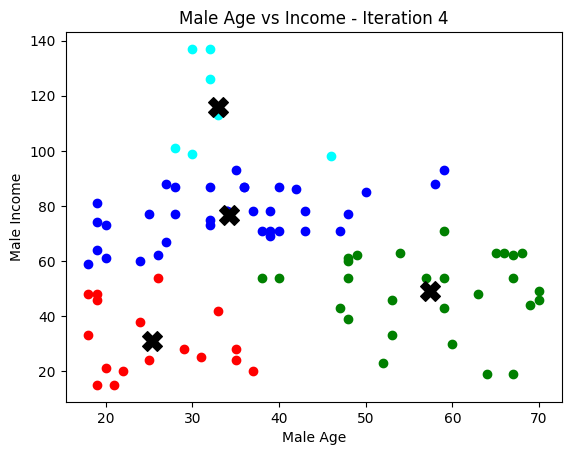

Updated centroids: [[25.352941176470587, 31.11764705882353], [34.25, 76.72222222222223], [57.42857142857143, 49.07142857142857], [33.0, 115.85714285714286]]


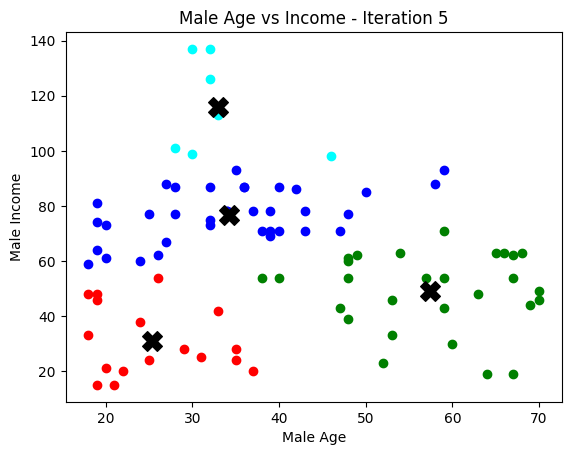

Updated centroids: [[25.352941176470587, 31.11764705882353], [34.25, 76.72222222222223], [57.42857142857143, 49.07142857142857], [33.0, 115.85714285714286]]
{'cluster': 3, 'size': 7, 'mean': array([ 33.        , 115.85714286]), 'median': array([ 32., 113.]), 'std': array([ 5.52914357, 16.16370335]), 'min': array([28, 98]), 'max': array([ 46, 137])}


In [ ]:
male_clusters_age__income = k_means_clustering_algorithm(male_age, male_income, "Male Age", "Male Income", "Male Age vs Income")

for cluster_num in male_clusters_age__income:
    stats = cluster_stats(male_clusters_age__income[cluster_num], cluster_num, male_age, male_income)

    print(stats)

Initial centroids: [[30.0, 60.0], [60.0, 60.0]]


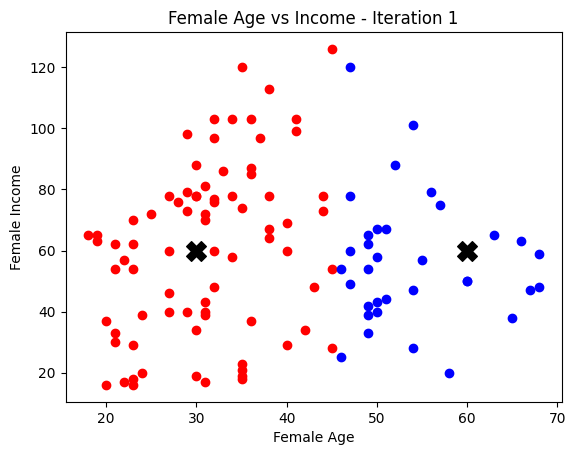

Updated centroids: [[31.205128205128204, 60.52564102564103], [53.911764705882355, 56.3235294117647]]


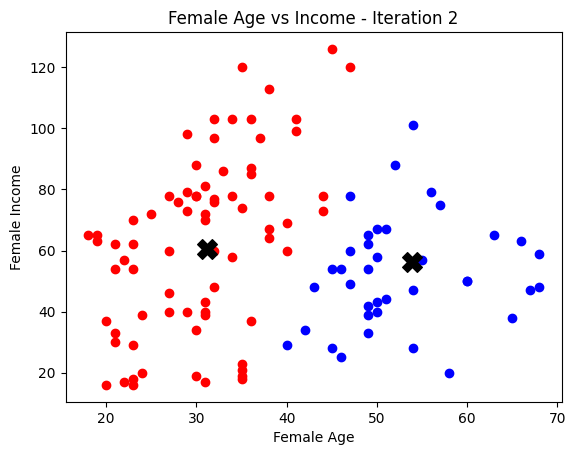

Updated centroids: [[30.62162162162162, 62.810810810810814], [52.6578947368421, 52.31578947368421]]


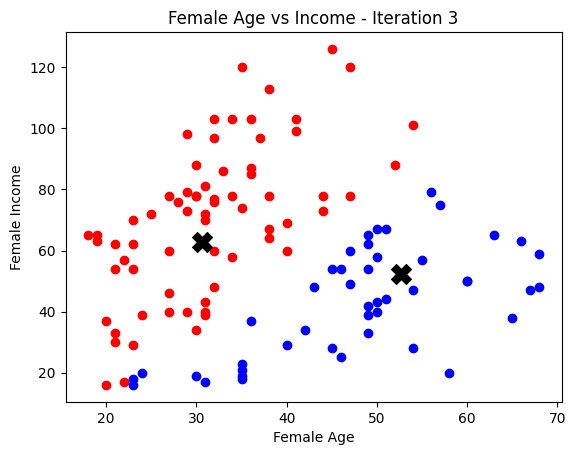

Updated centroids: [[31.52238805970149, 70.25373134328358], [47.888888888888886, 42.86666666666667]]


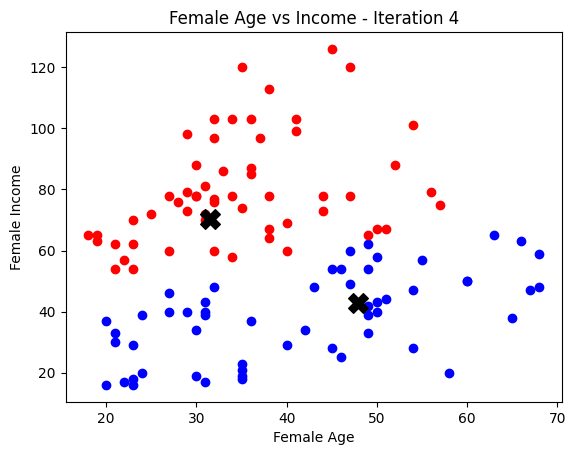

Updated centroids: [[34.8421052631579, 79.45614035087719], [41.472727272727276, 38.30909090909091]]


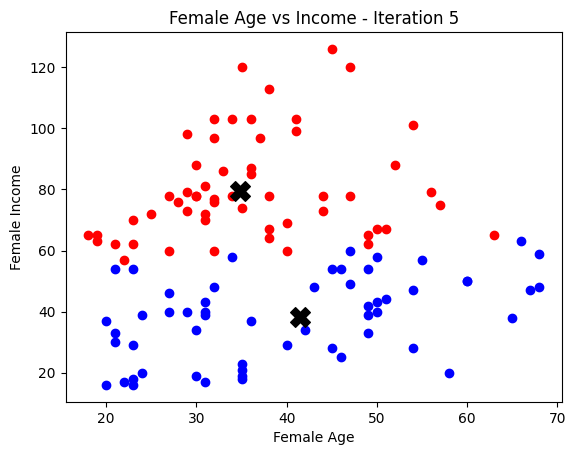

Updated centroids: [[36.07142857142857, 80.17857142857143], [40.125, 38.32142857142857]]
{'cluster': 0, 'size': 56, 'mean': array([36.07142857, 80.17857143]), 'median': array([34.5, 77.5]), 'std': array([10.26063411, 16.79403289]), 'min': array([18, 57]), 'max': array([ 63, 126])}


In [ ]:
female_clusters_age__income = k_means_clustering_algorithm(female_age, female_income, "Female Age", "Female Income", "Female Age vs Income")

for cluster_num in female_clusters_age__income:
    stats = cluster_stats(female_clusters_age__income[cluster_num], cluster_num, female_age, female_income)

    print(stats)

## Age Vs Spending Score

Initial centroids: [[30.0, 80.0], [60.0, 40.0]]


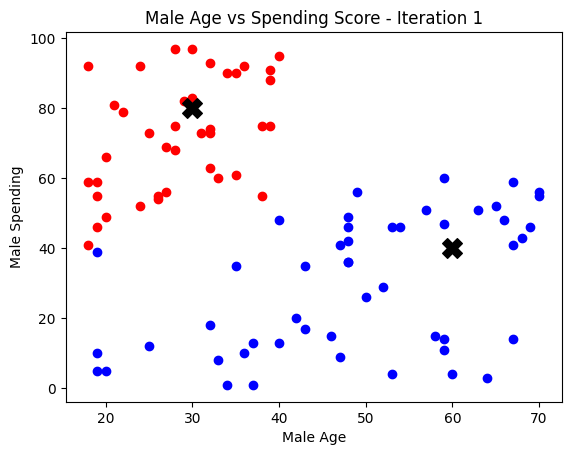

Updated centroids: [[28.487179487179485, 72.51282051282051], [48.816326530612244, 29.408163265306122]]


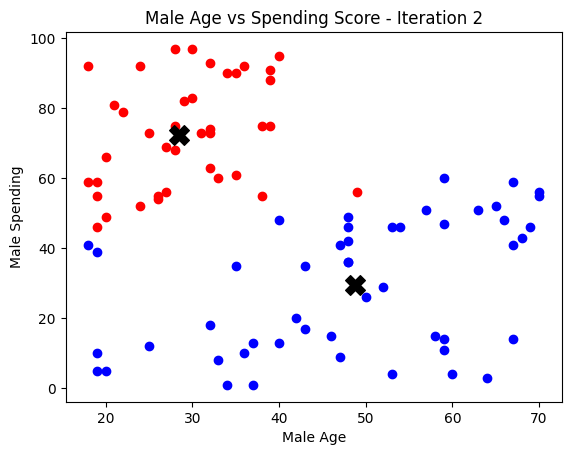

Updated centroids: [[29.28205128205128, 72.8974358974359], [48.183673469387756, 29.102040816326532]]


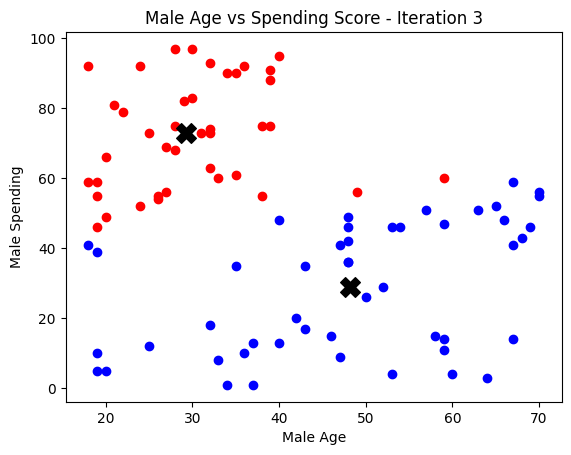

Updated centroids: [[30.025, 72.575], [47.958333333333336, 28.458333333333332]]


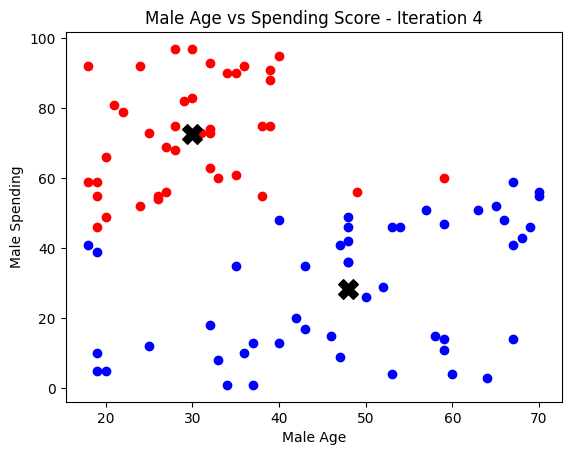

Updated centroids: [[30.025, 72.575], [47.958333333333336, 28.458333333333332]]


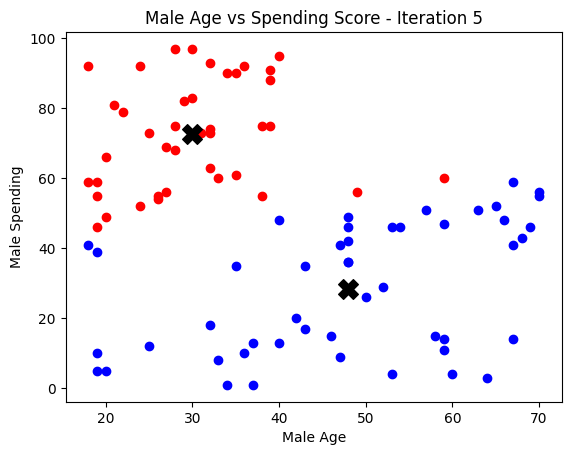

Updated centroids: [[30.025, 72.575], [47.958333333333336, 28.458333333333332]]
{'cluster': 0, 'size': 40, 'mean': array([30.025, 72.575]), 'median': array([29.5, 73. ]), 'std': array([ 8.59792853, 15.21000904]), 'min': array([18, 46]), 'max': array([59, 97])}


In [ ]:
male_clusters_age__spending = k_means_clustering_algorithm(male_age, male_spending, "Male Age", "Male Spending", "Male Age vs Spending Score")

for cluster_num in male_clusters_age__spending:
    stats = cluster_stats(male_clusters_age__spending[cluster_num], cluster_num, male_age, male_spending)

    print(stats)

Initial centroids: [[30.0, 80.0], [50.0, 33.0]]


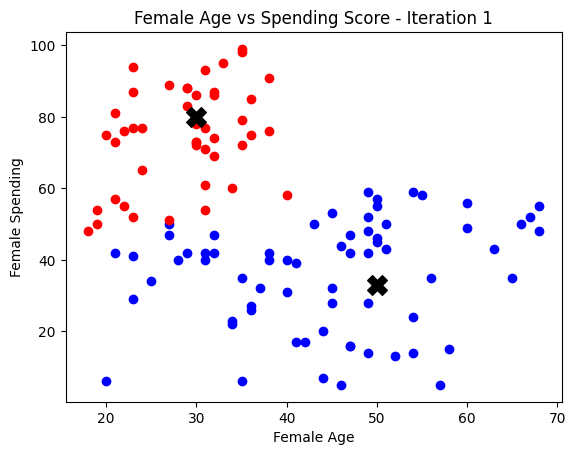

Updated centroids: [[28.711111111111112, 74.71111111111111], [44.40298507462686, 35.95522388059702]]


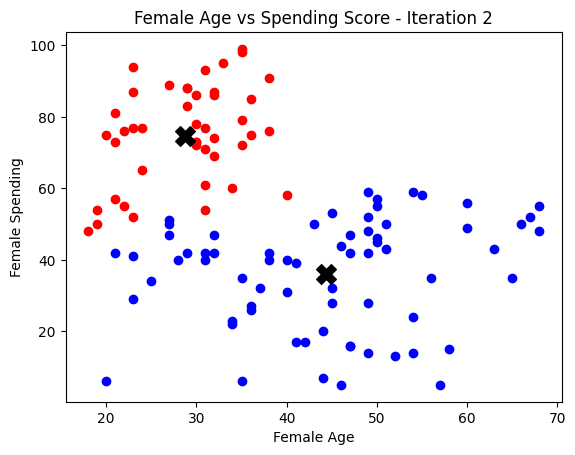

Updated centroids: [[28.75, 75.25], [44.14705882352941, 36.1764705882353]]


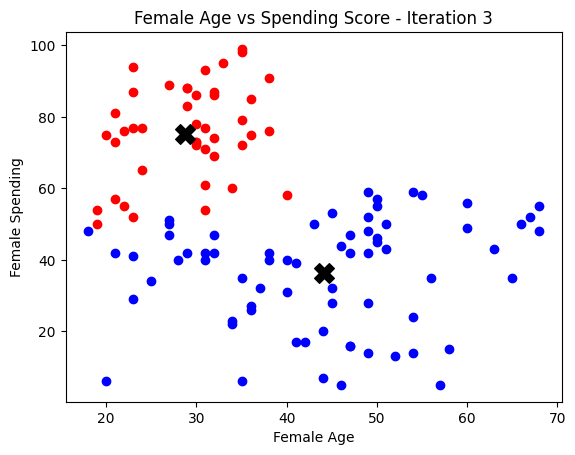

Updated centroids: [[29.0, 75.88372093023256], [43.768115942028984, 36.34782608695652]]


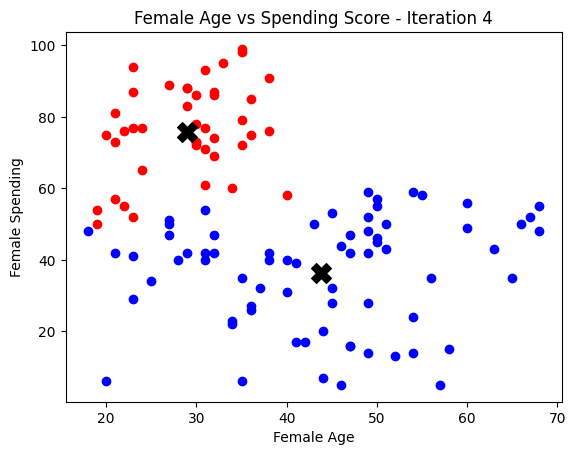

Updated centroids: [[28.952380952380953, 76.4047619047619], [43.58571428571429, 36.6]]


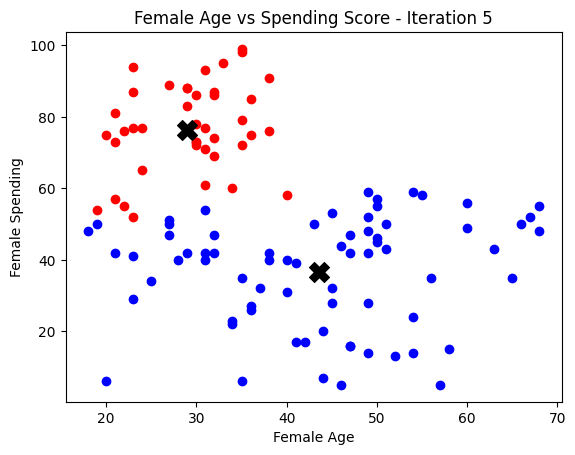

Updated centroids: [[29.195121951219512, 77.04878048780488], [43.23943661971831, 36.7887323943662]]
{'cluster': 0, 'size': 41, 'mean': array([29.19512195, 77.04878049]), 'median': array([30., 77.]), 'std': array([ 5.61018026, 12.26128394]), 'min': array([19, 52]), 'max': array([40, 99])}


In [ ]:
female_clusters_age__spending = k_means_clustering_algorithm(female_age, female_spending, "Female Age", "Female Spending", "Female Age vs Spending Score")

for cluster_num in female_clusters_age__spending:
    stats = cluster_stats(female_clusters_age__spending[cluster_num], cluster_num, female_age, female_spending)

    print(stats)

## Corelation Coefficients

In [15]:
# Male Correlations
m_age_income_cc = dal.find_data_correlation(male_age, male_income)
m_age_score_cc = dal.find_data_correlation(male_age, male_spending)
m_spending_income_cc = dal.find_data_correlation(male_income, male_spending)

# Female Correlations
f_age_income_cc = dal.find_data_correlation(female_age, female_income)
f_age_score_cc = dal.find_data_correlation(female_age, female_spending)
f_spending_income_cc = dal.find_data_correlation(female_income, female_spending)

print(f"Male Age vs Income Correlation Coefficient: {m_age_income_cc}")
print(f"Male Age vs Spending Score Correlation Coefficient: {m_age_score_cc}")
print(f"Male Income vs Spending Score Correlation Coefficient: {m_spending_income_cc}") 

print(f"Female Age vs Income Correlation Coefficient: {f_age_income_cc}")
print(f"Female Age vs Spending Score Correlation Coefficient: {f_age_score_cc}")
print(f"Female Income vs Spending Score Correlation Coefficient: {f_spending_income_cc}")

Male Age vs Income Correlation Coefficient: -0.09297809301080724
Male Age vs Spending Score Correlation Coefficient: -0.2796276462749313
Male Income vs Spending Score Correlation Coefficient: -0.02368420375597229
Female Age vs Income Correlation Coefficient: 0.05991212789455605
Female Age vs Spending Score Correlation Coefficient: -0.37543858377804734
Female Income vs Spending Score Correlation Coefficient: 0.04754211694903909
